# **Урок 6**. Делаем всё сразу: детектируем и сегментируем

В лекции мы с вами узнали всё про метрики для детектирования, а также познакомились с семейством two-stage-детекторов: `R-CNN`. 

Вершиной прогресса в `R-CNN`-детекторах является модель для `instance` сегментации — [Mask R-CNN](https://arxiv.org/abs/1703.06870), с ней мы и повзаимодействуем в рамках этой практики, а именно: попробуем зафайнтюнить предобученную сеть на конкретный датасет. 

## **План**

1. Готовим данные
2. Разбираемся с Mask R-CNN
3. Пробуем затюнить модель

Погнали!

## **1. Готовим данные**

Эксперименты будем проводить с маленьким открытым датасетом [Penn-Fudan
Database for Pedestrian Detection and
Segmentation](https://www.cis.upenn.edu/~jshi/ped_html/) для инстанс-сегментации. В нём всего 170 фото и 345 инстанс масок силуэтов пешеходов.

Скачаем архив с данными по прямой ссылке:

In [ ]:
! wget https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip

И разархивируем его (-q == quiet):

In [ ]:
! unzip -q PennFudanPed.zip

Важная нам структура датасета такова:

    PennFudanPed/
      PedMasks/
        FudanPed00001_mask.png
        FudanPed00002_mask.png
        FudanPed00003_mask.png
        FudanPed00004_mask.png
        ...
      PNGImages/
        FudanPed00001.png
        FudanPed00002.png
        FudanPed00003.png
        FudanPed00004.png

Также там есть отдельные файлики с описанием аннотации для каждой картинки, но нам, как и раньше, важны только парочки картинка-маска.

Давайте провизуализируем пример из нашего датасета.

In [1]:
import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

import torchvision

from torch.utils.data import DataLoader
from torch.optim import SGD 
from torch.optim.lr_scheduler import StepLR
from torchvision import tv_tensors
from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes

from torchvision.transforms import v2 as T
from torchvision.transforms.v2 import functional as F
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks

device = 'cuda:3'

In [2]:
def fix_everything(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
        
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.backends.cudnn.benchmark = False
    
    
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    

fix_everything(24)

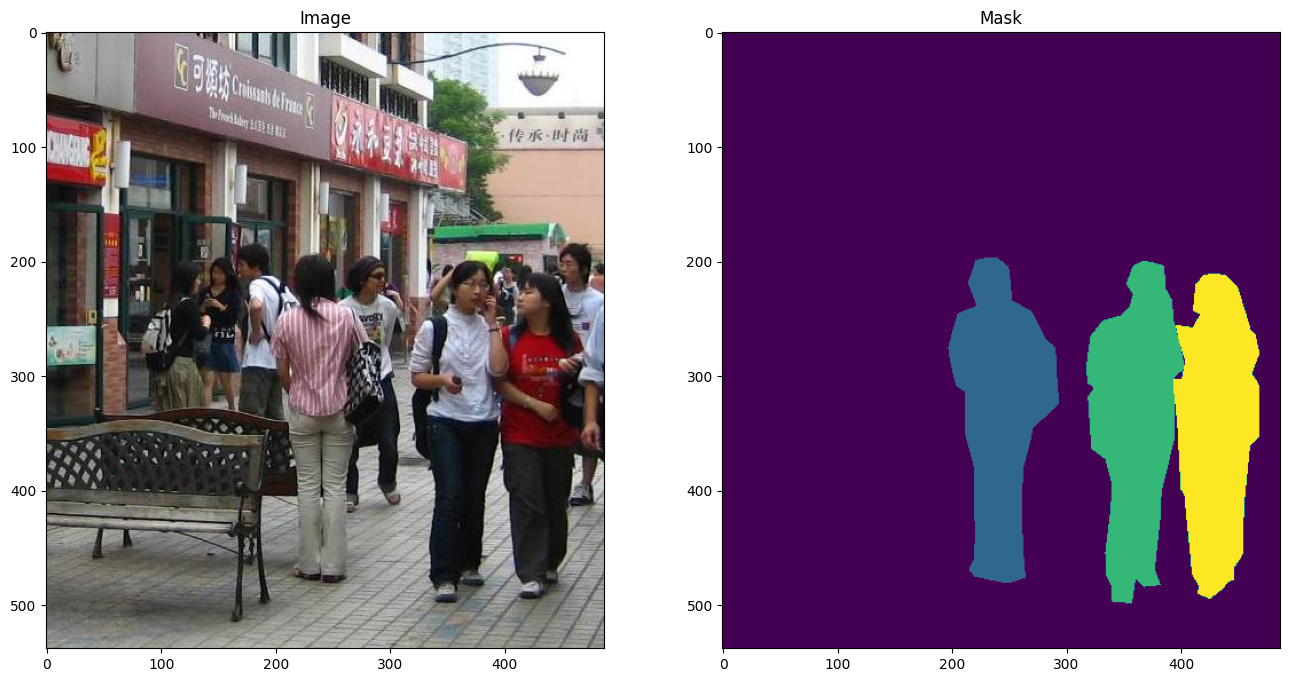

In [3]:
image = read_image('PennFudanPed/PNGImages/FudanPed00045.png')
mask = read_image('PennFudanPed/PedMasks/FudanPed00045_mask.png')

plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title('Image')
plt.imshow(image.permute(1, 2, 0))
plt.subplot(122)
plt.title('Mask')
plt.imshow(mask.permute(1, 2, 0))

In [4]:
# проверим, какие значения есть в маске
np.unique(mask)

array([0, 1, 2, 3], dtype=uint8)

Итак, у нас есть фото и соответствующий ему тензор из масок — у каждой маски свой лейбл, но соответствуют разные лейблы не разным классам, а разным объектам одного класса — инстансам.

Для подготовки данных для обучения, нам надо написать для них `Dataset`, этим и займёмся.

Как мы помним, самое главное для `Dataset` — это определить метод `__getitem__`. 

Для задачи детектирования есть стандартная библиотека для подсчёта метрик - `pycocotools` (ставится через `pip install pycocotools`). Если подготовить `Dataset` в правильном формате, то можно будет использовать её и облегчить себе жизнь. Так что давайте посмотрим, как подготовить данные в нужном формате.

В данном случае `__getitem__` должен возвращать `tuple`:

-   `image`: 1- или 3-х канальное изображение
-   `target`: `dict` со следующими полями:
    -   `boxes`, размера `[N, 4]`, где `N` — число боксов на картинке, формат боксов — `[x0, y0, x1, y1]`, диапазон значений от `[0, W]`, `[0, H]`,
    -   `labels`, размера `[N]`, с лейблами боксов,  `0` - это **всегда** background класс,
    -   `image_id`, уникальный `id` для картинки,
    -   `area`, размера `[N]`, площади боксов. Они используются для подсчета метрик на `COCO`, чтобы разделить `AP_s`, `AP_m`, `AP_l`,
    -   `iscrowd`, размера `[N]`, бинарный лейбл для толпы. Если у бокса лейбл `iscrowd=True`, то он будет игнорироваться во время подсчета метрик,
    -   (опционально) `masks`, размера `[N, H, W]`: маски для каждого бокса

В прошлые разы для соответственной аугментации картинок и масок мы использовали `albumentations`, в этот раз давайте расширим наш кругозор и разберёмся, как делать аналогичное в `torchvision.transforms`.

Мы будем упаковывать картинки, боксы и маски с помощью `torchvision.tv_tensors.TVTensor`, чтобы `torchvision.trasnforms` могли правильно аугментировать маски и боксы. 

Картинки будут типа `torchvision.tv_tensors.Image`, боксы — `torchvision.tv_tensors.BoundingBoxes`, а маски — `torchvision.tv_tensors.Mask`. 
Подробности - в [доке](https://pytorch.org/vision/main/auto_examples/transforms/plot_transforms_getting_started.html#what-are-tvtensors).


In [5]:
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        
        # создаём списки фото и масок, сортируем, чтобы они совпадали по индексам
        self.imgs = list(sorted(os.listdir(os.path.join(root, 'PNGImages'))))
        self.masks = list(sorted(os.listdir(os.path.join(root, 'PedMasks'))))

    def __getitem__(self, idx):
        # собираем пути
        img_path = os.path.join(self.root, 'PNGImages', self.imgs[idx])
        mask_path = os.path.join(self.root, 'PedMasks', self.masks[idx])
        
        # читаем наши объекты                                                       
        img = read_image(img_path)
        mask = read_image(mask_path)
                                                               
        # получаем id инстансов
        obj_ids = torch.unique(mask)
        
        # удаляем id бэкграунда                                                       
        obj_ids = obj_ids[1:]
        num_objs = len(obj_ids) # считаем, сколько объектов

        # создаём для каждого инстанса отдельный канал с бинарной маской
        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)
        
        # используем готовую функцию для получения боксов из масок
        # дока https://pytorch.org/vision/main/generated/torchvision.ops.masks_to_boxes.html
        boxes = masks_to_boxes(masks)

        # вектор из лейблов одного класса
        labels = torch.ones((num_objs,), dtype=torch.int64)
        
        # уникальный id и площади боксов                                                     
        image_id = idx
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
                                                               
        # считаем, что crowd у нас нет
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # картинку оборачиваем в соответственный тип torchvision tv_tensors:
        img = tv_tensors.Image(img)
        
        # а все таргеты должны быть dict-ом (для albumentations было похоже, правда?)                                                      
        target = {}
        target['boxes'] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
        target['masks'] = tv_tensors.Mask(masks)
        target['labels'] = labels
        target['image_id'] = image_id
        target['area'] = area
        target['iscrowd'] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

Фух, собрали. Посмотрим, что у нас получилось. 

In [6]:
# заведем transform по-новому: с помощью list и Compose над ним
def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

In [7]:
# создадим два варианта датасета — для train/test-использования
dataset = PennFudanDataset('PennFudanPed', get_transform(train=True))
dataset_test = PennFudanDataset('PennFudanPed', get_transform(train=False))

# а теперь отделим части для трейна и теста
indices = torch.randperm(len(dataset)).tolist()
train_dataset = torch.utils.data.Subset(dataset, indices[:-40])
test_dataset = torch.utils.data.Subset(dataset_test, indices[-40:])

In [8]:
print(len(train_dataset))
print(len(test_dataset))

130
40


In [9]:
# функция для объединения объектов приходящих из Dataset, т. к. у нас пока нет Resize, а картинки бывают разного размера
# и они будут складываться zip-ами в list
def collate_fn(batch):
    return list(zip(*batch))

# заводим лоадеры
train_loader = DataLoader(
    train_dataset, 
    batch_size=2,
    shuffle=True, 
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=2, 
    collate_fn=collate_fn,
)

In [10]:
# что же у нас там будет
images, targets = next(iter(train_loader))

In [11]:
print(len(images))
print(images[0].shape)
print(images[1].shape)

2
torch.Size([3, 429, 565])
torch.Size([3, 430, 569])


In [12]:
targets[0]

{'boxes': tensor([[113., 121., 211., 402.]]),
 'masks': tensor([[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.uint8),
 'labels': tensor([1]),
 'image_id': 85,
 'area': tensor([27538.]),
 'iscrowd': tensor([0])}

Отлично, тут всё то, что мы и ожидали.

Итак, мы
- узнали, какие таргеты необходимо иметь для использования `pycocotools`
- подготовили `Dataset` в соответствии с этими требованиями
- получили `train/test loaders`

А значит, можно переходить к работе с моделью.

## **2. Разбираемся с Mask R-CNN**

Давайте ещё разок вспомним, что из себя представляет `Mask R-CNN`.

`Mask R-CNN` строится на основе `Faster R-CNN`, которая работает в две стадии и для каждого якорного бокса предсказывает вероятность наличия объекта, его класс, а также поправки для координат якорного бокса для уточнения положения объекта. 

`Mask R-CNN` имеет всё это + ещё одну голову, которая предсказывает маски для каждого бокса. К тому же, для проекции `RoI` тут используется более продвинутая процедура — `RoIAlign`, а также современный бэкбон с `FPN`. 

<p align="center">
  <a href="images/fpn.png"><img src=https://pytorch.org/tutorials/_static/img/tv_tutorial/tv_image04.png style="width:70%; height:50%;"/></a>
</p>

В коде `torchvision` модель устроена довольно сложно и состоит из нескольких частей. Давайте разбираться в [доке](https://pytorch.org/vision/main/models/mask_rcnn.html).

Информации там не очень много, но всегда можно закопаться и смотреть напрямую [source code](https://github.com/pytorch/vision/blob/main/torchvision/models/detection/mask_rcnn.py).

Если мы хотим взять стандартную `Mask R-CNN` с `ResNet-50-FPN`, заменить у неё последние слои и дотюнить на нашу задачу, то сделать это несложно:

In [13]:
# загружаем обученную на COCO модель
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights='DEFAULT')

In [14]:
# посмотрим, как она архитектурно выглядит
model

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

Как мы видим, в модель уже зашита нормализация и ресайз входящих картинок, что довольно необычно. Так часто делают, чтобы ускорить вычисление этих операций на инференсе, а также чтобы юзеры точно использовали то, что нужно для подготовки картинок. 

Также в сети видны уже знакомые нам стейджи из `ResNet50`, `FPN`, `RPN` и отдельные головы для предсказания боксов, классов и масок. Частей много, но мы не пугаемся.

Что же тут надо изменить, чтобы адаптировать сеть под нашу задачу?

Нам надо будет залезть в `box_predictor` и `mask_predictor` — выходные головы для предсказания.

In [15]:
# заимпортируем соответственные модули
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor # голова для предсказания боксов
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor # голова для предсказания масок

In [16]:
num_classes = 2  # 1 class (person) + background

# вытаскиваем параметр числа входных фичей
in_features = model.roi_heads.box_predictor.cls_score.in_features

# заменяем голову на аналогичную с нужным нам числом классов
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# то же самое делаем с головой для масок
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256

model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

In [17]:
# посмотрим, как изменились головы
model.roi_heads

RoIHeads(
  (box_roi_pool): MultiScaleRoIAlign(featmap_names=['0', '1', '2', '3'], output_size=(7, 7), sampling_ratio=2)
  (box_head): TwoMLPHead(
    (fc6): Linear(in_features=12544, out_features=1024, bias=True)
    (fc7): Linear(in_features=1024, out_features=1024, bias=True)
  )
  (box_predictor): FastRCNNPredictor(
    (cls_score): Linear(in_features=1024, out_features=2, bias=True)
    (bbox_pred): Linear(in_features=1024, out_features=8, bias=True)
  )
  (mask_roi_pool): MultiScaleRoIAlign(featmap_names=['0', '1', '2', '3'], output_size=(14, 14), sampling_ratio=2)
  (mask_head): MaskRCNNHeads(
    (0): Conv2dNormActivation(
      (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
    (1): Conv2dNormActivation(
      (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
    (2): Conv2dNormActivation(
      (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), paddin

Супер, теперь у нас всего два класса будут предсказываться на выходе — `background` и `person`. 

Давайте посмотрим, что модель вообще будет нам отдавать. На вход она ожидает `list` — список из тензоров картинок.

In [18]:
model.eval()
images, targets = next(iter(train_loader))
images = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
output = model(images)

In [19]:
print(len(output))
print(output[0].keys())

2
dict_keys(['boxes', 'labels', 'scores', 'masks'])


На выход модель отдаёт `dict`, что же в нем лежит:

In [20]:
print(output[0]['boxes'].shape)
print(output[0]['labels'].shape)
print(output[0]['scores'].shape)
print(output[0]['masks'].shape)

torch.Size([100, 4])
torch.Size([100])
torch.Size([100])
torch.Size([100, 1, 425, 544])


Так как класс у нас был всегда один, то и все приходящие ответы будут относиться к нему.

Однако в `.train()` режиме, кроме картинок, она ожидает и `targets`, чтобы посчитать по ним `loss`-ы, с которыми должна учиться. Это тоже захардкожено в реализации модели, собственный `loss` мы тут просто так не вставим.

In [21]:
model.train()
images, targets = next(iter(train_loader))
images = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
output = model(images, targets)

In [22]:
output

{'loss_classifier': tensor(0.6039, grad_fn=<NllLossBackward0>),
 'loss_box_reg': tensor(0.3532, grad_fn=<DivBackward0>),
 'loss_mask': tensor(3.6301, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>),
 'loss_objectness': tensor(0.0197, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>),
 'loss_rpn_box_reg': tensor(0.0192, grad_fn=<DivBackward0>)}

Итого мы:
- вспомнили, что из себя представляет `Mask R-CNN`
- узнали, как у версии модели из `torchvision` заменить количество классов
- посмотрели на структуру архитектуры модели в коде
- а также на особенности `forward`-а модели в `train` и `eval` режимах

Самое время её затюнить!

## **3. Пробуем затюнить модель**

Для чистоты эксперимента создадим заново модель, а также выберем все основные части для её обучения:

In [23]:
def get_model_instance_segmentation(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights='DEFAULT')
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )
    
    return model

In [24]:
model = get_model_instance_segmentation(num_classes=2)
_ = model.to(device)

In [25]:
class Config:
    seed = 24
    batch_size = 4
    n_epochs = 5 
    lr = 0.005

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=2,  
                          shuffle=True, pin_memory=True, drop_last=True, collate_fn=collate_fn,
                          worker_init_fn=seed_worker, generator=generator)

In [26]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = SGD(params, lr=config.lr, momentum=0.9, weight_decay=0.0005)
lr_scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

Мы определили все основные части для обучения. А как же этот детектор учить?

Тут мы могли бы написать очередной `train loop`, которые вы наверняка очень любите, но разработчики `torchivision` уже сделали это за нас в репозитории [`vision/references/`](https://github.com/pytorch/vision/tree/main/references/detection).

Давайте для разнообразия мы посмотрим, что там за код, и просто возьмём его к себе готовым вот так:

In [ ]:
%pip install pycocotools

In [ ]:
! wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py
! wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py
! wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py
! wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py
! wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py

В папке с этим ноутбуком у нас теперь появились все необходимые скрипты. 

Нам нужны функции `train_one_epoch` и `evaluate` из `engine.py` — это будет петля для обучения и функция для тестирования и подсчёта метрик. 

Остальные скрипты нужны для того, чтобы `train`/`evaluate` могли оттуда нужные функции подтянуть. 

В целом тут весь пайплайн обучения ничем не отличается от прошлых, ведь сложный `loss` уже зашит в модель.

In [27]:
from engine import train_one_epoch, evaluate

И пока будет идти тюнинг, посмотрим, что происходит в логах:

In [28]:
for epoch in range(config.n_epochs):
    print('---------------------------------------')
    print(f'TRAINING, EPOCH {epoch}')
    print('---------------------------------------')
    # тут произойдёт обучение
    train_one_epoch(model, optimizer, train_loader, device, epoch, print_freq=30)
    
    # шаг оптимайзера там не делается, будем сами шагать
    lr_scheduler.step()
    print('---------------------------------------')
    print('EVALUATION')
    print('---------------------------------------')
    # считаем метрики на тесте
    evaluate(model, test_loader, device=device)

print('Finised Training!')

---------------------------------------
TRAINING, EPOCH 0
---------------------------------------


/netapp/a.belozerova/projects/karpov.courses/cv_module/lesson_6/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/32]  eta: 0:00:58  lr: 0.000166  loss: 4.9483 (4.9483)  loss_classifier: 0.8476 (0.8476)  loss_box_reg: 0.1403 (0.1403)  loss_mask: 3.9420 (3.9420)  loss_objectness: 0.0172 (0.0172)  loss_rpn_box_reg: 0.0012 (0.0012)  time: 1.8332  data: 0.3635  max mem: 0
Epoch: [0]  [30/32]  eta: 0:00:00  lr: 0.005000  loss: 0.5846 (1.2130)  loss_classifier: 0.0975 (0.2221)  loss_box_reg: 0.2014 (0.2275)  loss_mask: 0.2488 (0.7380)  loss_objectness: 0.0081 (0.0167)  loss_rpn_box_reg: 0.0090 (0.0087)  time: 0.3425  data: 0.0002  max mem: 0
Epoch: [0]  [31/32]  eta: 0:00:00  lr: 0.005000  loss: 0.5652 (1.1899)  loss_classifier: 0.0833 (0.2169)  loss_box_reg: 0.2014 (0.2272)  loss_mask: 0.2488 (0.7209)  loss_objectness: 0.0081 (0.0162)  loss_rpn_box_reg: 0.0074 (0.0087)  time: 0.3440  data: 0.0003  max mem: 0
Epoch: [0] Total time: 0:00:12 (0.3950 s / it)
---------------------------------------
EVALUATION
---------------------------------------
creating index...
index created!
Test:  [ 0

Наиболее агрегированная метрика здесь — это `Average Precision (AP) @[IoU=0.50:0.95]`, которая считается отдельно для боксов и масок. И после 5-й эпохи она получилась `~0.82` и `~0.77` соответственно, а для `Average Precision (AP) @IoU=0.75` вообще за `0.95`. 


Кажется, затюнились мы хорошо, давайте на случайной картинке отрисуем результаты:

In [29]:
# берём случайную картинку, трансформируем
image = read_image('PennFudanPed/PNGImages/FudanPed00040.png')
eval_transform = get_transform(train=False)

# отдаём сетке и получаем ответы
model.eval()
with torch.no_grad():
    x = eval_transform(image)
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred = predictions[0]

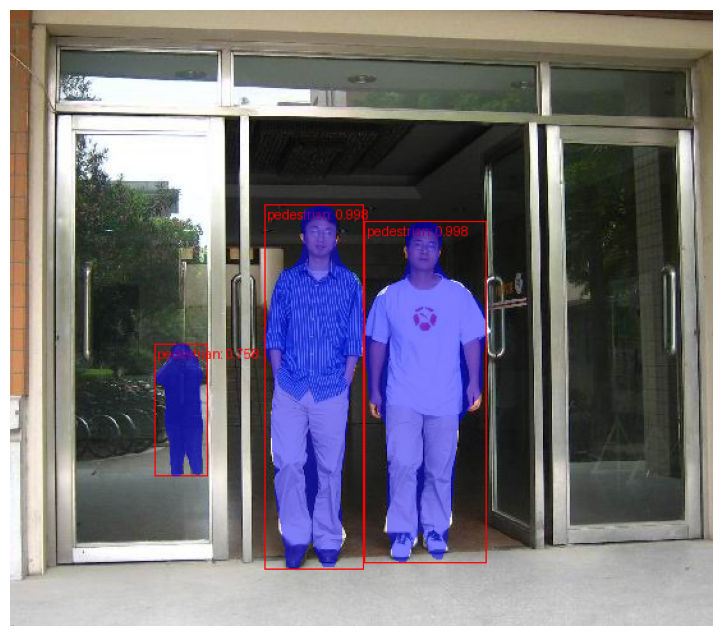

In [31]:
# формируем подписи
pred_labels = [f"pedestrian: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes = pred['boxes'].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red") # это функция из torch.utils

# считаем за маски только предсказания с score > 0.6
masks = (pred['masks'] > 0.5).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

plt.figure(figsize=(10, 8))
plt.axis('off')
plt.imshow(output_image.permute(1, 2, 0))

Выглядит офигенно, по-моему! 

Давайте подводить итоги.

## **Итоги**

В этой практике мы:

- подготовили `Dataset` с `target`-ом для `pycocotools`, где для каждой картинки были боксы, маски и их атрибуты
- разобрались, как в коде устроена `Mask R-CNN` и как можно, заменив ей голову, затюнить её на свой датасет со своим числом классов
- узнали, как модель работает в `train`/`eval` режимах
- научились брать готовые функции для обучения и эвала детектора в `vision/references`
- затюнили сетку и получили классные результаты — и по метрикам, и по визуализациям

Ай да мы!

Большей любовью к `Mask R-CNN` вы сможете проникнуться в домашнем задании, а у меня на сегодня всё. 

Продолжим знакомиться с детекторами в следующем уроке, 

See you!